In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV
from joblib import dump

---
# Load Dataset

In [2]:
df = pd.read_csv('../data/spam_processed.csv')

In [3]:
df.head()

,label,text
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


---
# Preprocessing

In [4]:
X = df['text']
y = df['label'].map({'ham': 0, 'spam': 1})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=101,
    stratify=y
)

In [6]:
tfidf = TfidfVectorizer()

---
# Training Base Model

### Rationale for Evaluation Metrics Selection

Given that our dataset is highly **imbalanced** (with a significantly larger proportion of 'ham' messages compared to 'spam'), evaluating models based solely on **Accuracy** can be highly misleading. A naive model that classifies every message as 'ham' would still yield a high accuracy, while failing completely to detect any spam.

Therefore, our evaluation strategy focuses strictly on the performance metrics of the minority class (**Spam / Class 1**):

1. **Precision (Spam):** This is our **primary critical metric**. It measures the percentage of messages flagged as spam that were actually spam. In a real-world scenario, a False Positive (classifying an important legitimate message or OTP code as spam) is far more detrimental to the user experience than a False Negative. Thus, we must ensure our Precision is exceptionally high.
2. **Recall (Spam):** This measures the proportion of actual spam messages that our model successfully captures. A low recall means more spam leaks into the user's main inbox.
3. **F1-Score (Spam):** Since optimizing Precision and Recall is often a trade-off, we use the F1-Score (the harmonic mean of Precision and Recall for the spam class) as our **ultimate baseline compass** to select and tune the best overall model.

We intentionally avoid using **Weighted Average F1-Score**, as it is heavily influenced by the majority 'ham' class and mask a model's poor performance in detecting actual spam.

In [7]:
def score_calc(cv: dict) -> dict:
    result = dict()
    
    result['accuracy_mean'] = cv['test_accuracy'].mean()
    result['accuracy_std'] = cv['test_accuracy'].std()
    
    result['f1_spam_mean'] = cv['test_f1_spam'].mean()
    result['f1_spam_std'] = cv['test_f1_spam'].std()
    
    result['precision_spam_mean'] = cv['test_precision_spam'].mean()
    result['precision_spam_std'] = cv['test_precision_spam'].std()
    
    result['recall_spam_mean'] = cv['test_recall_spam'].mean()
    result['recall_spam_std'] = cv['test_recall_spam'].std()
    
    return result

In [8]:
def base_model_training(x_data, y_data, tfidf_model, base_model):
    metrics = {
        'accuracy': 'accuracy',
        'f1_spam': 'f1',
        'precision_spam': 'precision',
        'recall_spam': 'recall'
    }
    
    pipe = Pipeline(steps=[
        ('tfidf', tfidf_model),
        ('model', base_model)
    ])
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)
    
    cv = cross_validate(
        estimator=pipe,
        X=x_data,
        y=y_data,
        scoring=metrics,
        cv=skf,
    )
    
    cv_result = score_calc(cv)
    
    return cv_result

In [9]:
models = {
    'naive_bayes': MultinomialNB(),
    'logistic_regression': LogisticRegression(random_state=101, max_iter=1_000_000),
    'svc': SVC(random_state=101, max_iter=1_000_000),
    'xgboost': XGBClassifier(random_state=101, eval_metric='logloss')
}

In [10]:
model_scores = dict()

for name, model in models.items():
    result = base_model_training(X_train, y_train, tfidf, model)
    model_scores[name] = result

In [11]:
scores_df = pd.DataFrame(data=model_scores.values(), index=model_scores.keys())

In [12]:
scores_df.transpose()

,naive_bayes,logistic_regression,svc,xgboost
accuracy_mean,0.945202,0.957811,0.975511,0.967752
accuracy_std,0.007470,0.007514,0.004554,0.004934
f1_spam_mean,0.715781,0.796473,0.891088,0.854017
f1_spam_std,0.047415,0.040927,0.021835,0.026611
precision_spam_mean,1.000000,0.988126,0.992954,0.971739
precision_spam_std,0.000000,0.010827,0.005768,0.017515
recall_spam_mean,0.559566,0.668704,0.809042,0.764306
recall_spam_std,0.059573,0.056256,0.038096,0.054307


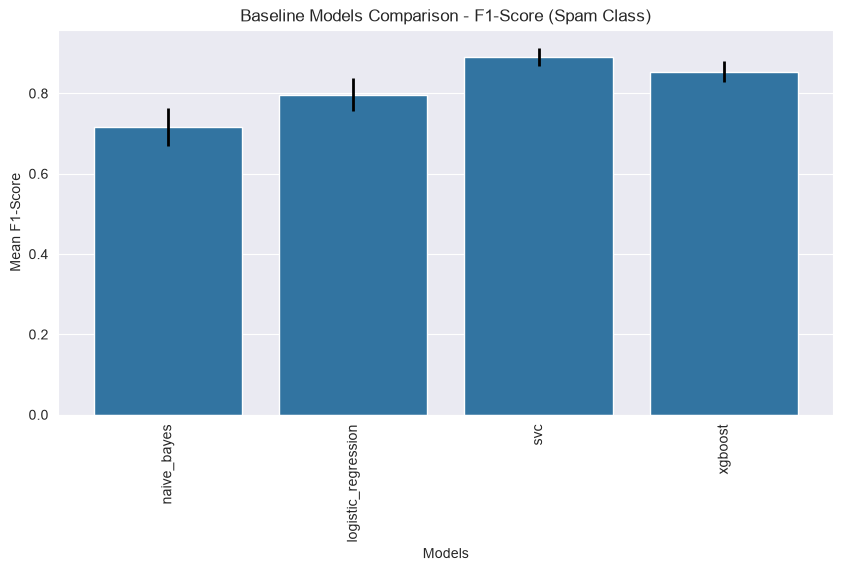

In [13]:
plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(data=scores_df, x=scores_df.index, y='f1_spam_mean')
plt.errorbar(
    x=np.arange(len(scores_df)),
    y=scores_df['f1_spam_mean'],
    yerr=scores_df['f1_spam_std'],
    fmt='none',
    c='black',
    lw=2
)
plt.title("Baseline Models Comparison - F1-Score (Spam Class)")
plt.ylabel("Mean F1-Score")
plt.xlabel("Models")
plt.xticks(rotation=90);

In [14]:
df_melted = scores_df[['precision_spam_mean', 'recall_spam_mean']].reset_index().melt(id_vars='index')

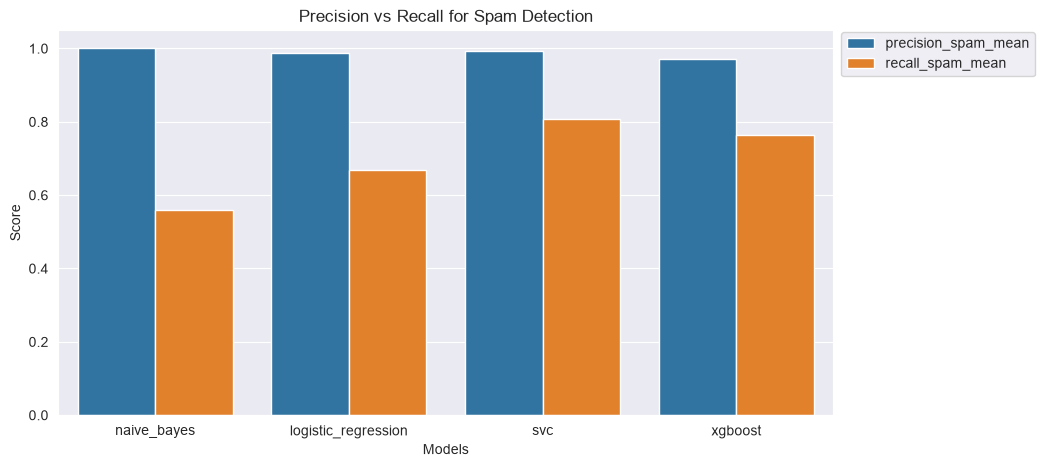

In [15]:
plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(data=df_melted, x='index', y='value', hue='variable')
plt.title("Precision vs Recall for Spam Detection")
plt.ylabel("Score")
plt.xlabel("Models")
plt.legend(loc=(1.01,0.88))
plt.show()

**Considering the score of each model, we find that the SVC model is better than the other models, so we use only the SVC model for the final model and for the tune stage.**

---
# Tune Best Model

In [16]:
best_model = models['svc']

In [17]:
pipeline = Pipeline(steps=[
    ('tfidf', tfidf),
    ('SVC', best_model)
])

In [18]:
grid_params = {
    'tfidf__max_features': [None, 3000, 5000],
    'SVC__kernel': ['linear', 'rbf', 'sigmoid'],
    'SVC__C': np.logspace(-2, 2, 5),
    'SVC__gamma': ['auto', 'scale'],
}

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [20]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_params,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

In [21]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=101))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'SVC__C': array([1.e-02...e+01, 1.e+02]), 'SVC__gamma': ['auto', 'scale'], 'SVC__kernel': ['linear', 'rbf', ...], 'tfidf__max_features': [None, 3000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more 

In [22]:
print("Best F1-Score on CV:", grid_search.best_score_)

Best F1-Score on CV: 0.9232148188428976


In [23]:
best_params = grid_search.best_params_

In [24]:
print("Best Parameters Found:", best_params)

Best Parameters Found: {'SVC__C': np.float64(10.0), 'SVC__gamma': 'auto', 'SVC__kernel': 'linear', 'tfidf__max_features': None}


---
# Evaluation Best Model

In [25]:
predict = grid_search.predict(X_test)

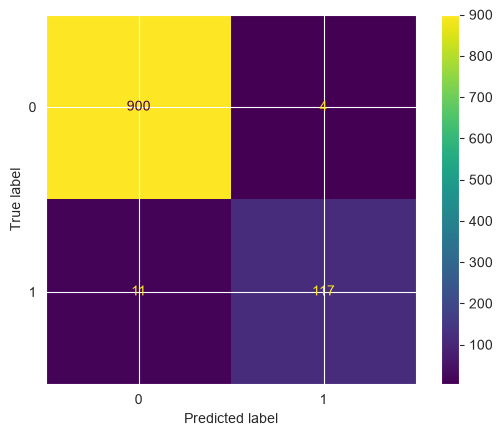

In [26]:
ConfusionMatrixDisplay.from_estimator(
    estimator=grid_search.best_estimator_,
    X=X_test,
    y=y_test,
);

In [27]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       904
           1       0.97      0.91      0.94       128

    accuracy                           0.99      1032
   macro avg       0.98      0.95      0.97      1032
weighted avg       0.99      0.99      0.99      1032



---
# Final Model Training

In [28]:
final_model = CalibratedClassifierCV(
    estimator=grid_search.best_estimator_,
    method='sigmoid',
    cv=skf
)

In [29]:
final_model.fit(X, y)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step..._state=101))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklea

---
# Test Model

In [30]:
def predict_spam(text):

    pred = final_model.predict([text])[0]
    prob = final_model.predict_proba([text])[0]

    label = "Spam" if pred == 1 else "Ham"
    prob = prob[1] if pred == 1 else prob[0]
    
    return {
        "prediction": label,
        f"{label}_probability": f"{prob:.2%}"
    }

In [31]:
print(predict_spam("FREE prize click now!!!"))
print(predict_spam("Don't forget to buy milk on your way home"))
print(predict_spam("URGENT! Your account has been selected. Click the link to get 500 dollars"))
print(predict_spam("Hey, are we still meeting for lunch tomorrow?"))


{'prediction': 'Spam', 'Spam_probability': '74.42%'}
{'prediction': 'Ham', 'Ham_probability': '97.19%'}
{'prediction': 'Spam', 'Spam_probability': '99.31%'}
{'prediction': 'Ham', 'Ham_probability': '99.98%'}


---
# Save Final Model

In [32]:
dump(final_model, '../final_model/spam_detector_model.pkl')

['../final_model/spam_detector_model.pkl']